In [8]:
!pip install  opencv-python-headless

DEPRECATION: Loading egg at /home/28s_mur@lab.graphicon.ru/miniconda3/envs/patch_attack/lib/python3.11/site-packages/resample2d_cuda-0.0.0-py3.11-linux-x86_64.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /home/28s_mur@lab.graphicon.ru/miniconda3/envs/patch_attack/lib/python3.11/site-packages/channelnorm_cuda-0.0.0-py3.11-linux-x86_64.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /home/28s_mur@lab.graphicon.ru/miniconda3/envs/patch_attack/lib/python3.11/site-packages/correlation_cuda-0.0.0-py3.11-linux-x86_64.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Disc

In [1]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Import RAFT from PTLFlow
import ptlflow
from ptlflow.utils import flow_utils
from ptlflow.utils.io_adapter import IOAdapter

# Import GradCAM and BaseCAMTarget from pytorch-grad-cam
from pytorch_grad_cam import GradCAM

import cv2 as cv
import matplotlib.pyplot as plt
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2"

[!!alt_cuda_corr is not compiled!!]


In [2]:
img1 = cv.imread('frame_0001.png')
img2 = cv.imread('frame_0002.png')
model = ptlflow.get_model('raft', pretrained_ckpt='things')
model.to('cuda')
model.eval()
io_adapter = IOAdapter(model, img1.shape[:2])
inputs = io_adapter.prepare_inputs([img1, img2])
inputs['images'] = inputs['images'].to('cuda')

In [3]:
predictions = model(inputs)

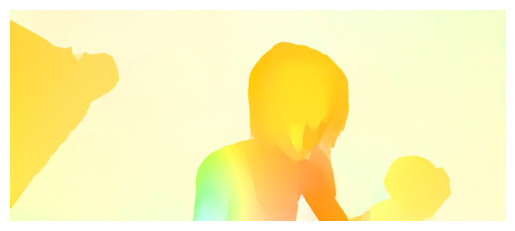

In [4]:
flow = predictions['flows'][0, 0]  # Remove batch and sequence dimensions
flow = flow.permute(1, 2, 0)  # change from CHW to HWC shape
flow = flow.detach().cpu().numpy()
flow_viz = flow_utils.flow_to_rgb(flow)  # Represent the flow as RGB colors
flow_viz = cv.cvtColor(flow_viz, cv.COLOR_BGR2RGB)  # OpenCV uses BGR format
plt.imshow(flow_viz)
plt.axis('off')  # Hide axis
plt.show()

In [5]:
# Use CUDA if available

input_tensor = inputs['images'][0]

# Create an instance of our custom target using the ground truth


In [6]:
inputs['images'].shape

torch.Size([1, 2, 3, 436, 1024])

In [7]:
target_flow = torch.zeros_like(predictions['flows'].squeeze(0))

In [8]:
class OpticalFlowRewardTarget:
    def __init__(self, ground_truth: torch.Tensor):
        """
        Args:
            ground_truth (torch.Tensor): Ground truth optical flow tensor of shape [B, 2, H, W].
        """
        super().__init__()
        self.ground_truth = ground_truth

    def __call__(self, model_output: torch.Tensor) -> torch.Tensor:
        # Compute endpoint error (EPE) per pixel: sqrt((F_x - GT_x)^2 + (F_y - GT_y)^2)
        epe = torch.sqrt(torch.sum((model_output - self.ground_truth) ** 2, dim=1))  # shape: [B, H, W]
        # Negative mean error so that lower error gives a higher reward
        return torch.mean(epe)
target = OpticalFlowRewardTarget(target_flow)

In [9]:
import torch.nn as nn

class RAFTWrapper(nn.Module):
    def __init__(self, raft_model):
        super().__init__()
        self.raft = raft_model

    def forward(self, x):
        """Wraps RAFT forward pass."""
        x = x[None, :]
        output = self.raft({'images': x})  # RAFT expects a dict
        return output['flows'][-1]  # Extract final flow prediction
wrapped_model = RAFTWrapper(model)
target_layer = wrapped_model.raft.fnet.conv2

In [10]:
def overlay_heatmap(heatmap, image):
    """
    Overlay a heatmap on an image.
    
    Args:
        heatmap (numpy.ndarray): 2D heatmap with values in [0, 1].
        image (numpy.ndarray): Original image (BGR format).
        
    Returns:
        numpy.ndarray: Overlay image.
    """
    # Resize heatmap to match image dimensions
    heatmap = cv2.resize(heatmap, (image.shape[1], image.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(image, 0.5, heatmap_color, 0.5, 0)
    return overlay

In [11]:
def apply_exponential_transformation(gradcam_map, gamma=2.0):
    """
    Применяет экспоненциальное преобразование к карте Grad-CAM.
    
    :param gradcam_map: входная карта активации (numpy array)
    :param gamma: коэффициент экспоненциального преобразования
    :return: преобразованная карта Grad-CAM
    """
    gradcam_map = np.clip(gradcam_map, 0, 1)  # Ограничиваем значения
    # Применяем экспоненциальное преобразование
    exp_map = np.power(gradcam_map, gamma)
    return exp_map / exp_map.max()  # Нормализация

In [12]:
import matplotlib.pyplot as plt


def plot_gradcam_histogram(grayscale_cam):
    """Построение гистограммы значений Grad-CAM"""
    plt.figure(figsize=(6, 4))
    plt.hist(grayscale_cam.flatten(), bins=50, color='blue', alpha=0.7)
    plt.xlabel("Intensity")
    plt.ylabel("Frequency")
    plt.title("Grad-CAM Heatmap Histogram")
    plt.show()

In [19]:
def apply_gradcam(model, input_tensor, target_layer, layer_name, img):
    """Applies Grad-CAM on the given target layer and visualizes the result."""
    with GradCAM(model=model, target_layers=[target_layer]) as cam:
        grayscale_cam = cam(input_tensor, targets=[target])[0]  # Compute Grad-CAM heatmap
        grayscale_cam = apply_exponential_transformation(grayscale_cam, gamma=0.5)
        # Overlay Grad-CAM heatmap
        overlay_image = overlay_heatmap(grayscale_cam, img)

        # Show the result
        plot_gradcam_histogram(grayscale_cam)
        plt.imshow(cv2.cvtColor(overlay_image, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.title(f"Grad-CAM Overlay for RAFT {layer_name}")
        plt.show()

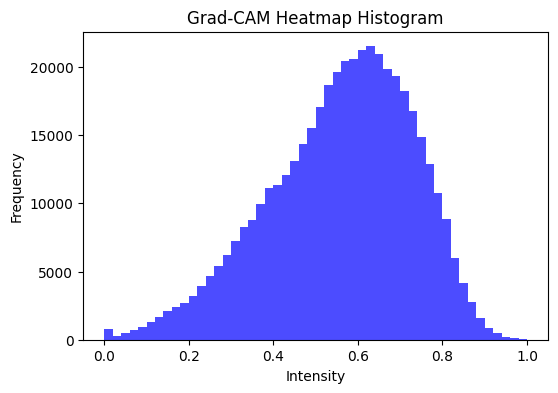

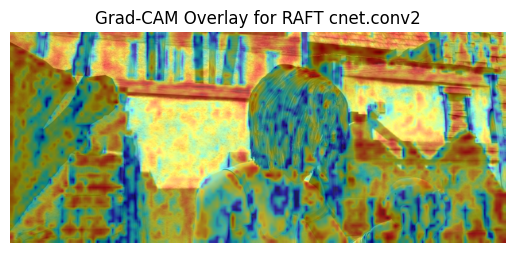

In [20]:
target_layer = wrapped_model.raft.cnet.conv2
layer_name = "cnet.conv2"
apply_gradcam(wrapped_model, input_tensor, target_layer, layer_name, img1)

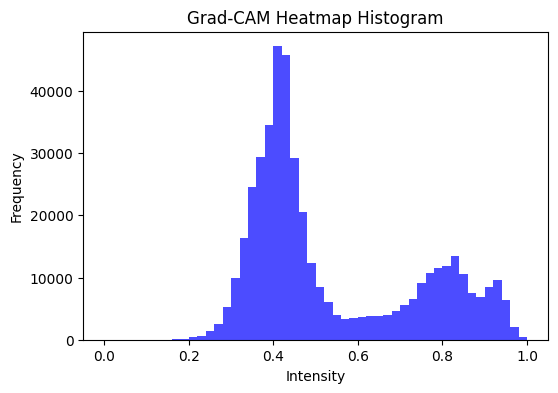

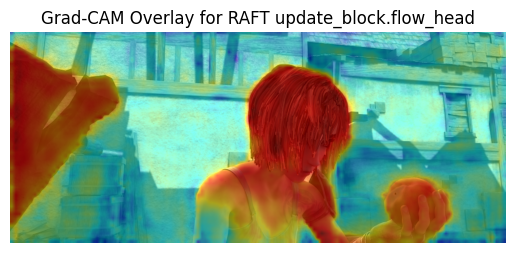

In [21]:
target_layer = wrapped_model.raft.update_block.flow_head
layer_name = "update_block.flow_head"
apply_gradcam(wrapped_model, input_tensor, target_layer, layer_name, img1)

In [23]:
def apply_sobel(images):
    """
    Вычисляет карту границ изображения с помощью оператора Собеля.
    :param images: Входные изображения (тензор [B, C, H, W])
    :return: Карта границ (тензор [B, 1, H, W])
    """
    images_np = images.detach().cpu().numpy()  # Переводим в numpy для OpenCV
    edge_maps = []

    for img in images_np:
        img_gray = np.mean(img, axis=0)  # Градации серого
        sobel_x = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=3)
        sobel_y = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=3)
        edge_map = np.sqrt(sobel_x**2 + sobel_y**2)  # Магнитуда градиента
        edge_map = edge_map / (edge_map.max() + 1e-8)  # Нормализация
        edge_maps.append(edge_map)

    edge_maps = np.array(edge_maps)[:, None, :, :]  # Добавляем канал
    return torch.tensor(edge_maps, device=images.device, dtype=images.dtype)

In [24]:
def apply_high_frequency_mask(images, kernel_size=5, sigma=1.0):
    """
    Вычисляет маску высоких частот путем вычитания размытых данных от исходного изображения.
    
    :param images: тензор изображений [B, C, H, W]
    :param kernel_size: размер ядра Гауссова размытия (нечетное число)
    :param sigma: стандартное отклонение для Гауссова размытия
    :return: тензор масок высоких частот [B, 1, H, W]
    """
    images_np = images.detach().cpu().numpy()
    hf_maps = []
    for img in images_np:
        # Усредняем по каналам для получения изображения в оттенках серого
        img_gray = np.mean(img, axis=0)
        # Применяем Гауссово размытие
        img_blur = cv2.GaussianBlur(
            img_gray, (kernel_size, kernel_size), sigma)
        # Вычисляем разницу (абсолютное значение) между исходным и размытым изображением
        hf = np.abs(img_gray - img_blur)
        # Нормализуем карту в диапазон [0, 1]
        hf = hf / (hf.max() + 1e-8)
        hf_maps.append(hf)

    hf_maps = np.array(hf_maps)[:, None, :, :]  # добавляем ось для канала
    return torch.tensor(hf_maps, device=images.device, dtype=images.dtype)

In [25]:
def apply_low_frequency_filter(images, kernel_size=5, sigma=1.0):
    """
    Вычисляет низкочастотное изображение через Гауссово размытие.
    
    :param images: тензор изображений [B, C, H, W]
    :param kernel_size: размер ядра Гауссова размытия
    :param sigma: стандартное отклонение Гауссова ядра
    :return: тензор низкочастотных изображений [B, C, H, W]
    """
    images_np = images.detach().cpu().numpy()
    low_freq_maps = []

    for img in images_np:
        blurred_channels = []
        for channel in img:  # Размываем каждый канал отдельно
            blurred = cv2.GaussianBlur(
                channel, (kernel_size, kernel_size), sigma)
            blurred_channels.append(blurred)

        # Восстанавливаем 3 канала
        blurred_img = np.stack(blurred_channels, axis=0)
        low_freq_maps.append(blurred_img)

    low_freq_maps = np.array(low_freq_maps)
    return torch.tensor(low_freq_maps, device=images.device, dtype=images.dtype)

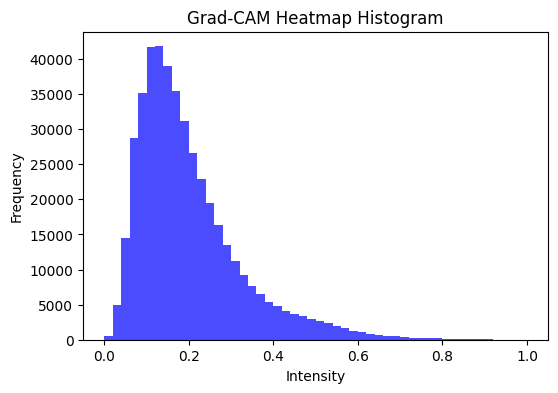

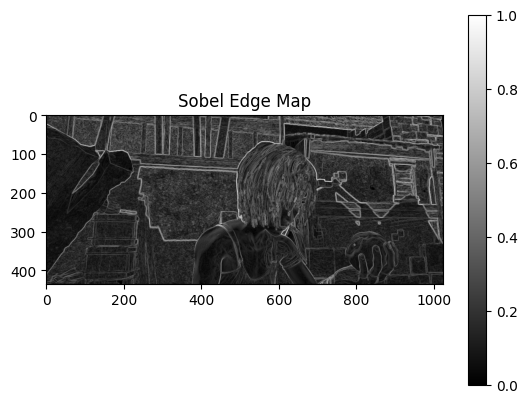

In [30]:
sobel_map = apply_sobel(input_tensor)  # [B, 1, H, W]

# Берём 1-е изображение из батча и убираем канал
sobel_np = sobel_map[0, 0].cpu().numpy()  # Превращаем в numpy
sobel_np =apply_exponential_transformation(sobel_np, gamma=0.5)
plot_gradcam_histogram(sobel_np)

# Выводим с помощью matplotlib
plt.imshow(sobel_np, cmap="gray")
plt.colorbar()  # Добавляет шкалу значений
plt.title("Sobel Edge Map")
plt.show()

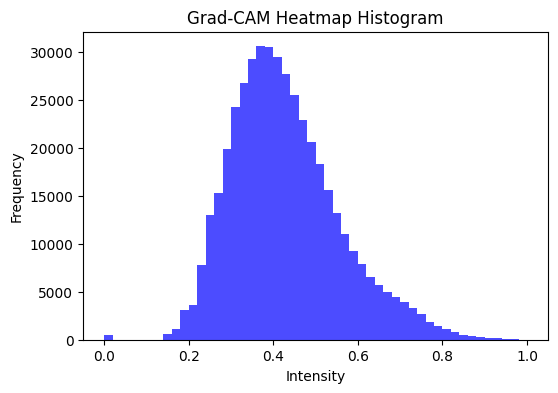

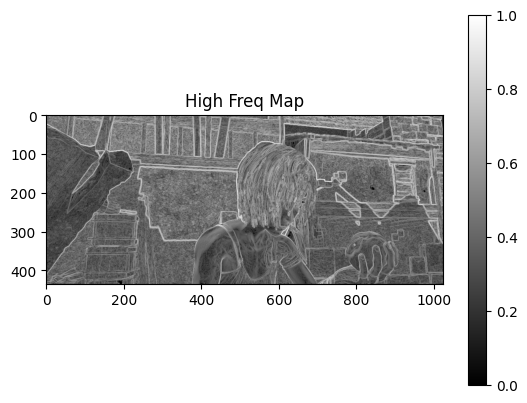

In [31]:
sobel_map = apply_high_frequency_mask(input_tensor)  # [B, 1, H, W]

# Берём 1-е изображение из батча и убираем канал
sobel_np = apply_exponential_transformation(sobel_np, gamma=0.5)
plot_gradcam_histogram(sobel_np)
# Выводим с помощью matplotlib
plt.imshow(sobel_np, cmap="gray")
plt.colorbar()  # Добавляет шкалу значений
plt.title("High Freq Map")
plt.show()

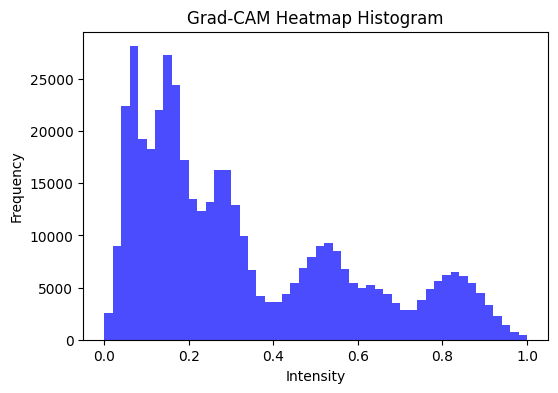

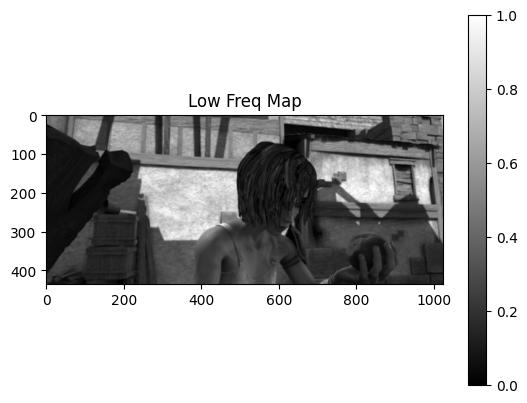

In [33]:
sobel_map = apply_low_frequency_filter(input_tensor)  # [B, 1, H, W]

# Берём 1-е изображение из батча и убираем канал
sobel_np = sobel_map[0, 0].cpu().numpy()  # Превращаем в numpy
sobel_np = apply_exponential_transformation(sobel_np, gamma=1)
plot_gradcam_histogram(sobel_np)
# Выводим с помощью matplotlib
plt.imshow(sobel_np, cmap="gray")
plt.colorbar()  # Добавляет шкалу значений
plt.title("Low Freq Map")
plt.show()

In [ ]:
import gc

wrapped_model.cpu()
del wrapped_model
gc.collect()
torch.cuda.empty_cache()